# EDA — Online Retail II
1,067,371 transactions, UK gift wholesaler, Dec 2009 – Dec 2011.
Run cells with the "Run Cell" links, or Shift+Enter.

In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})
NAVY, BLUE, AMBER, RED = "#243B6B", "#3E7CB1", "#E0A458", "#B23A48"

## 1. What arrived

In [2]:
from src.config import load_config
from src.ingest import load_transactions, profile

cfg = load_config("../config.yaml")
raw, prov = load_transactions(cfg)
print(f"rows {len(raw):,} | invoices {raw.invoice_no.nunique():,} | "
      f"products {raw.stock_code.nunique():,} | customers {raw.customer_id.nunique():,} | "
      f"countries {raw.country.nunique()}")
print(f"period {raw.invoice_date.min():%d %b %Y} -> {raw.invoice_date.max():%d %b %Y}")
profile(raw)

rows 1,067,371 | invoices 53,628 | products 5,304 | customers 5,942 | countries 43
period 01 Dec 2009 -> 09 Dec 2011


,column,dtype,nulls,null_pct,distinct,sample
0,invoice_no,string,0,0.00,53628,489434
1,stock_code,string,0,0.00,5304,85048
2,description,string,4382,0.41,5698,15CM CHRISTMAS GLASS BALL 20
3,quantity,int64,0,0.00,1057,12
4,invoice_date,datetime64[ns],0,0.00,47635,2009-12-01 07:45:00
5,unit_price,float64,0,0.00,2807,6.95
6,customer_id,string,243007,22.77,5942,13085
7,country,string,0,0.00,43,United Kingdom


## 2. Missing data
customer_id is ~23% null. Those are guest checkouts — real sales, not junk.
Decision: keep for revenue, exclude from RFM and cohorts.

In [3]:
raw["line_revenue"] = raw.quantity * raw.unit_price
raw["is_guest"] = raw.customer_id.isna()
g = raw.groupby("is_guest").agg(lines=("invoice_no", "size"),
                                invoices=("invoice_no", "nunique"),
                                revenue=("line_revenue", "sum"))
g["share_pct"] = (100 * g.revenue / g.revenue.sum()).round(1)
print(g)

           lines  invoices       revenue  share_pct
is_guest                                           
False     824364     44876 16,648,292.39      86.30
True      243007      8752  2,638,958.18      13.70


## 3. Cancellations — the rows most analyses delete

In [4]:
raw["is_cancel"] = raw.invoice_no.astype(str).str.upper().str.startswith("C")
gross = raw.loc[~raw.is_cancel, "line_revenue"].sum()
rets = raw.loc[raw.is_cancel, "line_revenue"].sum()
print(f"gross GBP {gross:,.2f} | returns GBP {rets:,.2f} | net GBP {gross+rets:,.2f}")
print(f"return rate {abs(rets)/gross:.2%}  (raw file; pipeline reports 6.65% after "
      f"removing duplicates and service lines)")
print(f"deleting cancellations would overstate revenue by {abs(rets)/(gross+rets):.2%}")

gross GBP 20,813,918.43 | returns GBP -1,526,667.86 | net GBP 19,287,250.57
return rate 7.33%  (raw file; pipeline reports 6.65% after removing duplicates and service lines)
deleting cancellations would overstate revenue by 7.92%


One row breaks the rule — a manual adjustment posted onto a credit note.
That single row is why the validation rule binds product lines only.

In [5]:
odd = raw[(raw.is_cancel) & (raw.quantity > 0)]
print(f"cancellations with positive quantity: {len(odd)}")
odd[["invoice_no", "stock_code", "description", "quantity", "unit_price"]]

cancellations with positive quantity: 1


,invoice_no,stock_code,description,quantity,unit_price
76799,C496350,M,Manual,1,373.57


## 4. Prices and quantities

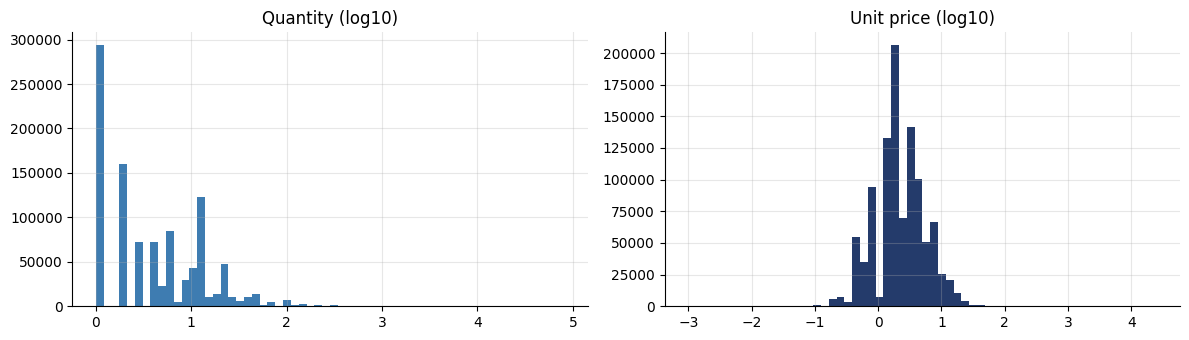

,count,mean,std,min,1%,50%,99%,max
quantity,"1,067,371.00",9.94,172.71,"-80,995.00",-3.00,3.00,100.00,"80,995.00"
unit_price,"1,067,371.00",4.65,123.55,"-53,594.36",0.21,2.10,18.00,"38,970.00"


In [6]:
sale = raw[(~raw.is_cancel) & (raw.quantity > 0) & (raw.unit_price > 0)].copy()
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].hist(np.log10(sale.quantity), bins=60, color=BLUE); ax[0].set_title("Quantity (log10)")
ax[1].hist(np.log10(sale.unit_price), bins=60, color=NAVY); ax[1].set_title("Unit price (log10)")
plt.tight_layout(); plt.show()
raw[["quantity", "unit_price"]].describe(percentiles=[.01, .5, .99]).T

Zero-price rows are warehouse annotations, not products.

In [7]:
zero = raw[raw.unit_price <= 0]
print(f"lines with price <= 0: {len(zero):,}")
zero.description.fillna("(null)").str.strip().str.upper().value_counts().head(10)

lines with price <= 0: 6,207


description
(NULL)                   4382
CHECK                     165
DAMAGED                    99
?                          92
DAMAGES                    89
FOUND                      38
MISSING                    30
AMAZON                     21
SOLD AS SET ON DOTCOM      20
ADJUSTMENT                 18
Name: count, dtype: Int64

## 5. Non-product stock codes
POST, DOT, M, BANK CHARGES, AMAZONFEE, vouchers — real money, not products.

In [8]:
codes = raw.stock_code.astype(str).str.strip().str.upper()
mask = ~codes.str.match(r"^\d{5}")
(raw[mask].assign(code=codes[mask]).groupby("code")
   .agg(lines=("invoice_no", "size"), revenue=("line_revenue", "sum"))
   .sort_values("lines", ascending=False).head(12))

,lines,revenue
code,,
POST,2122,"112,341.00"
DOT,1446,"322,647.47"
M,1426,"-82,781.27"
C2,282,"13,386.00"
D,177,"-13,484.54"
S,104,"-6,065.80"
BANK CHARGES,102,"-35,562.63"
ADJUST,67,"6,835.24"
AMAZONFEE,43,"-260,763.58"


## 6. Time — seasonality and hour of day

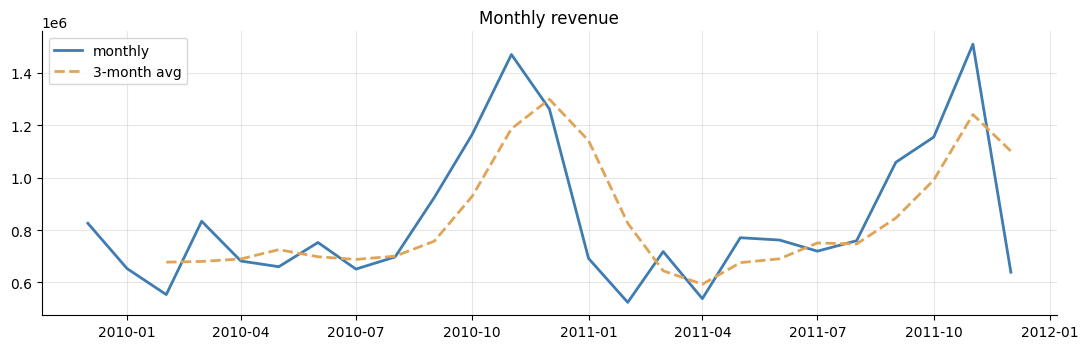

Seasonal index (1.00 = average month):
invoice_date
1    0.77
2    0.62
3    0.89
4    0.70
5    0.82
6    0.87
7    0.78
8    0.83
9    1.13
10   1.33
11   1.70
12   1.56


In [9]:
monthly = sale.set_index("invoice_date").resample("MS").line_revenue.sum().to_frame("revenue")
monthly["rolling3"] = monthly.revenue.rolling(3).mean()
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(monthly.index, monthly.revenue, color=BLUE, lw=2, label="monthly")
ax.plot(monthly.index, monthly.rolling3, color=AMBER, lw=2, ls="--", label="3-month avg")
ax.legend(); ax.set_title("Monthly revenue"); plt.tight_layout(); plt.show()
print("Seasonal index (1.00 = average month):")
s = sale.groupby(sale.invoice_date.dt.month).line_revenue.sum()
print((s / s.mean()).round(2).to_string())

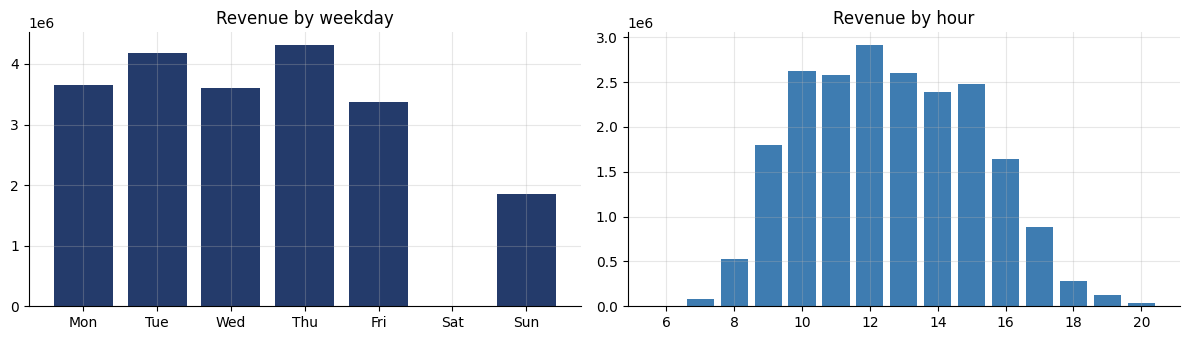

trading 06:00-20:00 | 10:00-15:00 is 74.3% of revenue -> B2B ordering pattern


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
dow = sale.groupby(sale.invoice_date.dt.dayofweek).line_revenue.sum()
dow.index = [["Mon","Tue","Wed","Thu","Fri","Sat","Sun"][i] for i in dow.index]
ax[0].bar(dow.index, dow.values, color=NAVY); ax[0].set_title("Revenue by weekday")
hour = sale.groupby(sale.invoice_date.dt.hour).line_revenue.sum()
ax[1].bar(hour.index, hour.values, color=BLUE); ax[1].set_title("Revenue by hour")
plt.tight_layout(); plt.show()
mid = sale[sale.invoice_date.dt.hour.between(10, 15)].line_revenue.sum()
print(f"trading {sale.invoice_date.dt.hour.min():02d}:00-{sale.invoice_date.dt.hour.max():02d}:00 | "
      f"10:00-15:00 is {mid/sale.line_revenue.sum():.1%} of revenue -> B2B ordering pattern")

## 7. Geography — the UK problem

UK share: 85.21%  -> chart exports separately


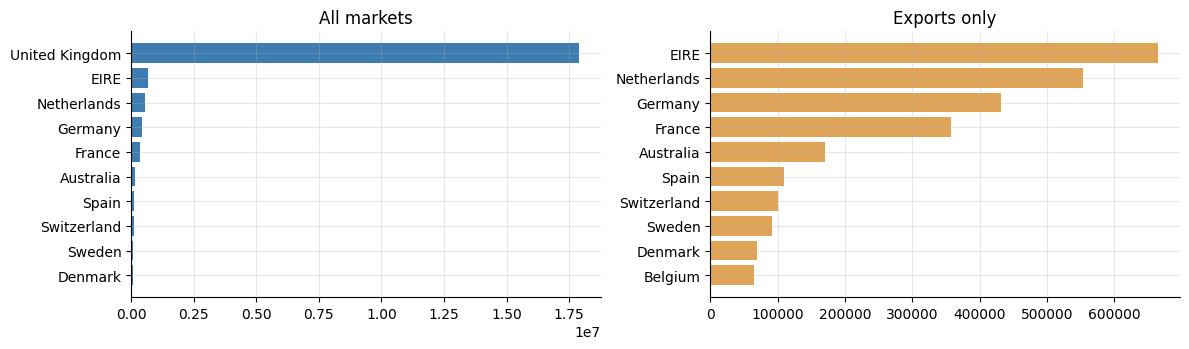

,revenue,invoices,share_pct,aov
country,,,,
United Kingdom,"17,870,977.78",36535,85.21,489.15
EIRE,"664,431.78",626,3.17,"1,061.39"
Netherlands,"554,232.34",228,2.64,"2,430.84"
Germany,"431,262.46",789,2.06,546.59
France,"356,944.60",622,1.70,573.87
Australia,"169,968.11",95,0.81,"1,789.14"
Spain,"109,178.53",154,0.52,708.95
Switzerland,"101,011.29",93,0.48,"1,086.14"
Sweden,"91,903.72",105,0.44,875.27


In [11]:
geo = (sale.groupby("country").agg(revenue=("line_revenue","sum"),
                                   invoices=("invoice_no","nunique"))
          .sort_values("revenue", ascending=False))
geo["share_pct"] = (100 * geo.revenue / geo.revenue.sum()).round(2)
geo["aov"] = (geo.revenue / geo.invoices).round(2)
print(f"UK share: {geo.loc['United Kingdom','share_pct']}%  -> chart exports separately")
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
t = geo.head(10); ax[0].barh(t.index[::-1], t.revenue[::-1], color=BLUE)
ax[0].set_title("All markets")
e = geo.drop("United Kingdom").head(10); ax[1].barh(e.index[::-1], e.revenue[::-1], color=AMBER)
ax[1].set_title("Exports only")
plt.tight_layout(); plt.show()
geo.head(10)

## 8. Product concentration (Pareto)

1,037 of 4,905 products (21.1%) make 80% of revenue
bottom half of the catalogue: 4.24%


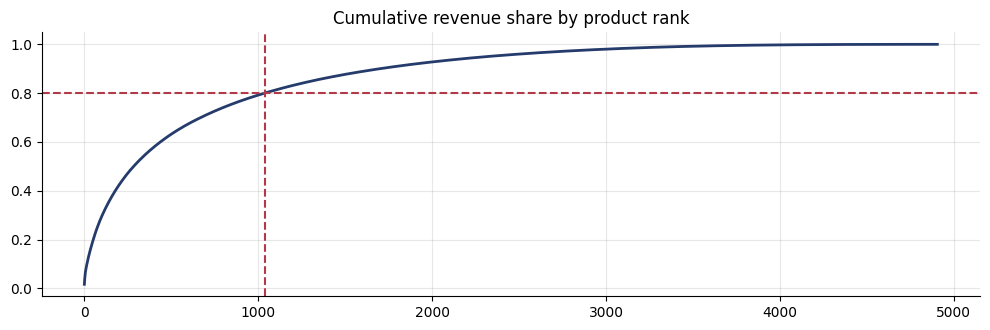

In [12]:
svc = ["POST","DOT","M","C2","D","S","B","BANK CHARGES","AMAZONFEE","CRUK","PADS"]
prod = (sale[~codes.reindex(sale.index).isin(svc)]
        .groupby("stock_code").line_revenue.sum().sort_values(ascending=False))
cum = prod.cumsum() / prod.sum()
n80 = int((cum <= .80).sum()) + 1
print(f"{n80:,} of {len(prod):,} products ({n80/len(prod):.1%}) make 80% of revenue")
print(f"bottom half of the catalogue: {prod.tail(len(prod)//2).sum()/prod.sum():.2%}")
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(np.arange(1, len(cum)+1), cum.values, color=NAVY, lw=2)
ax.axhline(.8, color=RED, ls="--"); ax.axvline(n80, color=RED, ls="--")
ax.set_title("Cumulative revenue share by product rank"); plt.tight_layout(); plt.show()

## 9. Customers

customers 5,878 | repeat 72.4% | median orders 3 | top 10% = 63.9% of revenue


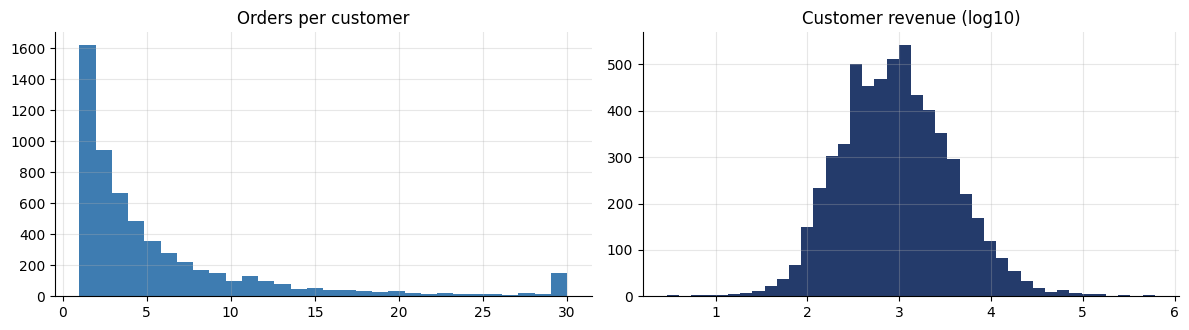

In [13]:
cust = (sale[sale.customer_id.notna()].groupby("customer_id")
          .agg(orders=("invoice_no","nunique"), revenue=("line_revenue","sum")))
top10 = cust.nlargest(max(len(cust)//10, 1), "revenue").revenue.sum()
print(f"customers {len(cust):,} | repeat {(cust.orders>1).mean():.1%} | "
      f"median orders {cust.orders.median():.0f} | top 10% = {top10/cust.revenue.sum():.1%} of revenue")
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].hist(cust.orders.clip(upper=30), bins=30, color=BLUE); ax[0].set_title("Orders per customer")
ax[1].hist(np.log10(cust.revenue.clip(lower=1)), bins=40, color=NAVY); ax[1].set_title("Customer revenue (log10)")
plt.tight_layout(); plt.show()

## 10. Seaborn — distributions and correlation
Rule-of-thumb charts above; statistical ones here.

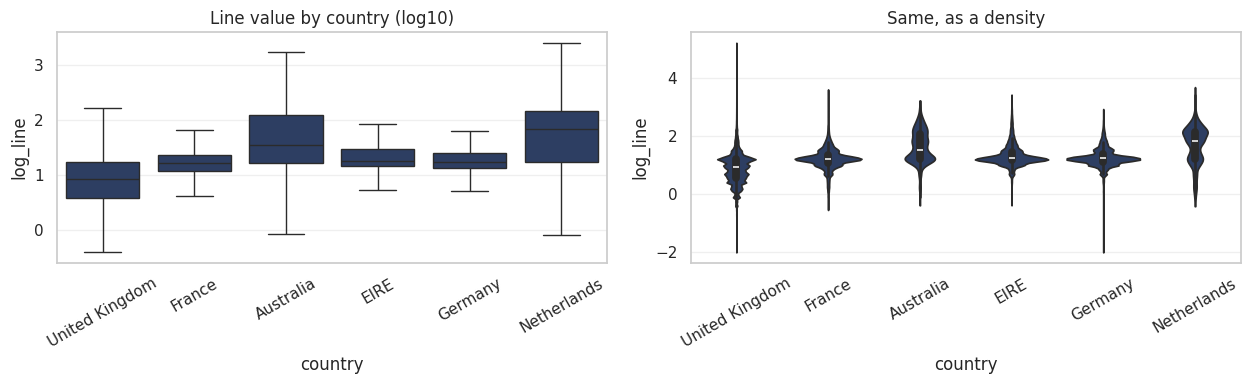

In [14]:
import seaborn as sns
sns.set_theme(style="whitegrid", palette=[NAVY, BLUE, AMBER, RED])

top6 = geo.head(6).index.tolist()
sub = sale[sale.country.isin(top6)].copy()
sub["log_line"] = np.log10(sub.line_revenue.clip(lower=.01))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=sub, x="country", y="log_line", ax=ax[0], showfliers=False)
ax[0].set_title("Line value by country (log10)"); ax[0].tick_params(axis="x", rotation=30)
sns.violinplot(data=sub, x="country", y="log_line", ax=ax[1], cut=0)
ax[1].set_title("Same, as a density"); ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

Correlation between the numeric features. Weak correlations here are the
finding: price and quantity are close to independent, which is why revenue
concentration comes from *volume* rather than from expensive products.

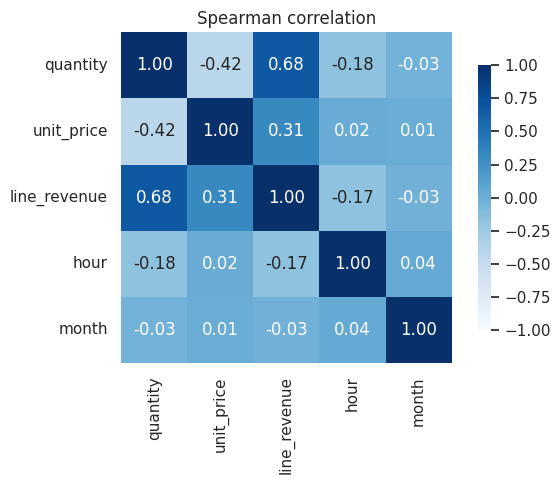

In [15]:
feat = sale.assign(
    hour=sale.invoice_date.dt.hour,
    month=sale.invoice_date.dt.month,
)[["quantity", "unit_price", "line_revenue", "hour", "month"]]

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(feat.corr(method="spearman"), annot=True, fmt=".2f", cmap="Blues",
            vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"shrink": .8})
ax.set_title("Spearman correlation")
plt.tight_layout(); plt.show()

## 11. RFM features for clustering
The SQL layer scores RFM with NTILE - business rules, fixed cut points.
Here we let the data choose its own segments and compare.

              mean    50%        max
recency     200.33  95.00     738.00
frequency     6.29   3.00     398.00
monetary  3,018.62 898.91 608,821.65


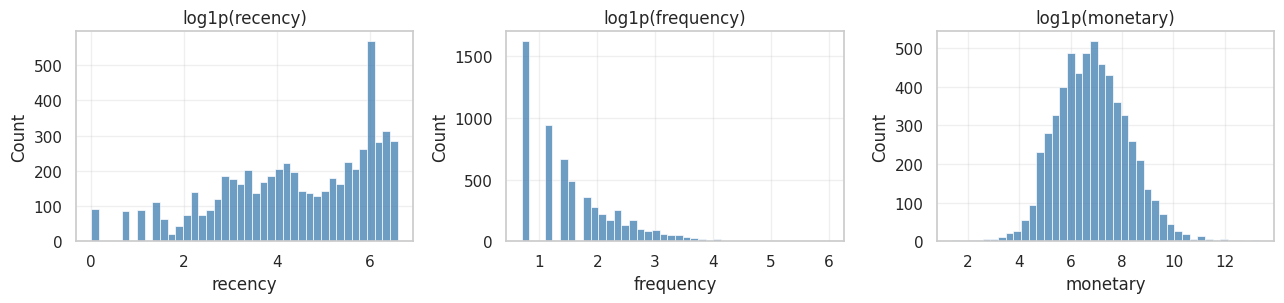

In [16]:
asof = sale.invoice_date.max()
rfm = (sale[sale.customer_id.notna()].groupby("customer_id").agg(
        recency=("invoice_date", lambda s: (asof - s.max()).days),
        frequency=("invoice_no", "nunique"),
        monetary=("line_revenue", "sum")))
rfm = rfm[rfm.monetary > 0]
print(rfm.describe().T[["mean", "50%", "max"]])

fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
for a, c in zip(ax, ["recency", "frequency", "monetary"]):
    sns.histplot(np.log1p(rfm[c]), bins=40, ax=a, color=BLUE)
    a.set_title(f"log1p({c})")
plt.tight_layout(); plt.show()

## 12. scikit-learn — KMeans segmentation
RFM is heavily skewed, so log-transform before scaling. Skipping that step
produces clusters that are really just "one enormous customer vs everyone".

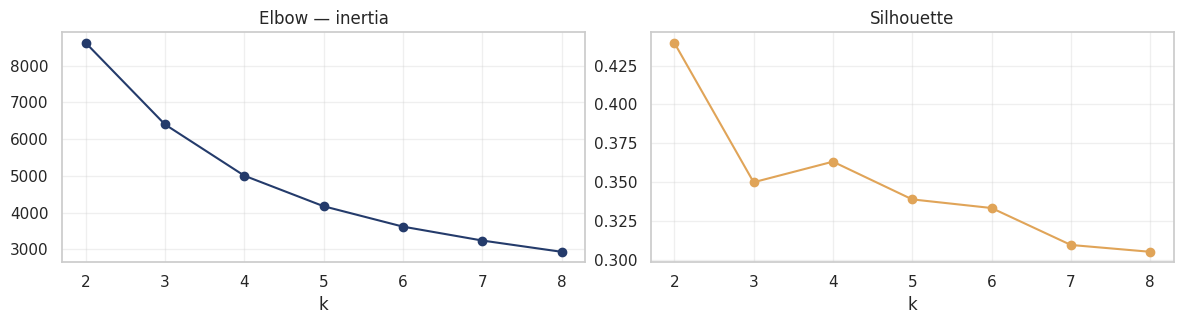

best silhouette at k=2 (0.440)


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

X = np.log1p(rfm[["recency", "frequency", "monetary"]])
Xs = StandardScaler().fit_transform(X)

scores = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xs)
    scores[k] = (km.inertia_, silhouette_score(Xs, km.labels_, sample_size=3000,
                                               random_state=42))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].plot(list(scores), [v[0] for v in scores.values()], "o-", color=NAVY)
ax[0].set_title("Elbow — inertia"); ax[0].set_xlabel("k")
ax[1].plot(list(scores), [v[1] for v in scores.values()], "o-", color=AMBER)
ax[1].set_title("Silhouette"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.show()

best_k = max(scores, key=lambda k: scores[k][1])
print(f"best silhouette at k={best_k} ({scores[best_k][1]:.3f})")

In [18]:
K = 4
km = KMeans(n_clusters=K, n_init=10, random_state=42).fit(Xs)
rfm["cluster"] = km.labels_

profile_ = (rfm.groupby("cluster")
              .agg(customers=("monetary", "size"),
                   recency=("recency", "median"),
                   frequency=("frequency", "median"),
                   monetary=("monetary", "median"),
                   revenue=("monetary", "sum")))
profile_["revenue_share"] = (100 * profile_.revenue / profile_.revenue.sum()).round(1)
print(profile_)

         customers  recency  frequency  monetary       revenue  revenue_share
cluster                                                                      
0             2061   399.00       1.00    295.09    708,655.52           4.00
1             1115    15.00      13.00  5,356.23 12,802,747.77          72.20
2             1212    22.00       3.00    744.19  1,044,541.99           5.90
3             1490   162.00       5.00  1,612.92  3,187,483.90          18.00


Naming the clusters from their centroids, rather than assuming which is which.

In [19]:
names = {}
for c, row in profile_.iterrows():
    if row.frequency >= profile_.frequency.median() and row.recency <= profile_.recency.median():
        names[c] = "Loyal / high value"
    elif row.recency > profile_.recency.median() and row.monetary >= profile_.monetary.median():
        names[c] = "At risk - was valuable"
    elif row.recency > profile_.recency.median():
        names[c] = "Lapsed"
    else:
        names[c] = "New / occasional"
rfm["segment"] = rfm.cluster.map(names)
print(rfm.segment.value_counts().to_frame("customers"))

                        customers
segment                          
Lapsed                       2061
At risk - was valuable       1490
New / occasional             1212
Loyal / high value           1115


## 13. PCA — seeing the clusters in two dimensions
Three RFM features compressed to two components, purely to make the
separation visible. The variance explained tells you how much to trust it.

variance explained: 95.1%


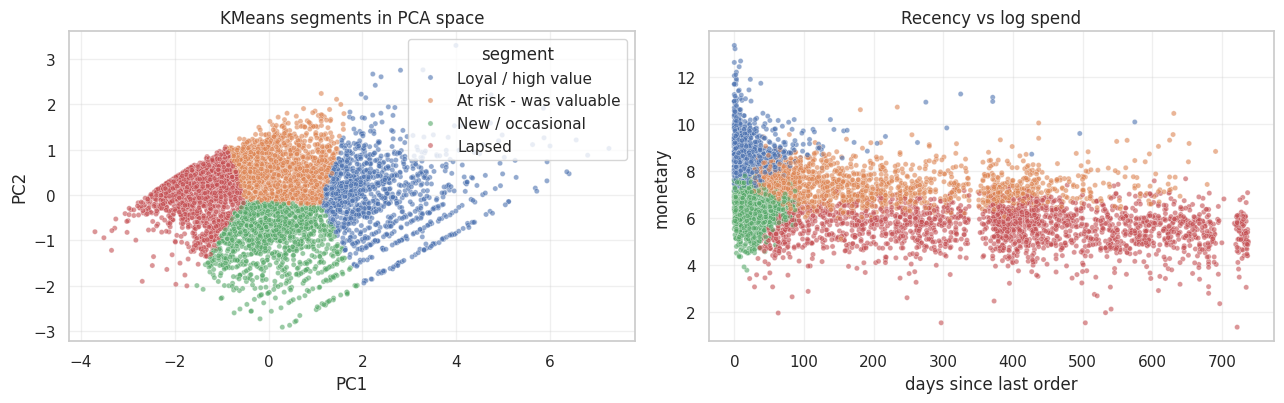

In [20]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(Xs)
print(f"variance explained: {pca.explained_variance_ratio_.sum():.1%}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
sns.scatterplot(x=pcs[:, 0], y=pcs[:, 1], hue=rfm.segment, s=14, alpha=.6,
                ax=ax[0], palette="deep")
ax[0].set_title("KMeans segments in PCA space"); ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2")
sns.scatterplot(x=rfm.recency, y=np.log1p(rfm.monetary), hue=rfm.segment,
                s=14, alpha=.6, ax=ax[1], palette="deep", legend=False)
ax[1].set_title("Recency vs log spend"); ax[1].set_xlabel("days since last order")
plt.tight_layout(); plt.show()

## 14. Isolation Forest — unusual customers
Not "big spenders" - the detector looks for combinations that are odd across
all three features at once, which is what a single-column outlier rule misses.

flagged 118 of 5,878 customers (2.0%)
             recency  frequency   monetary             segment
customer_id                                                   
14911              0        398 295,972.63  Loyal / high value
18102              0        145 608,821.65  Loyal / high value
15311              0        208 116,771.16  Loyal / high value
17949              0        118 118,628.08  Loyal / high value
14646              1        151 528,602.52  Loyal / high value
12748              0        336  56,599.39  Loyal / high value
13798              0        110  75,836.87  Loyal / high value
13089              2        203 116,737.86  Loyal / high value


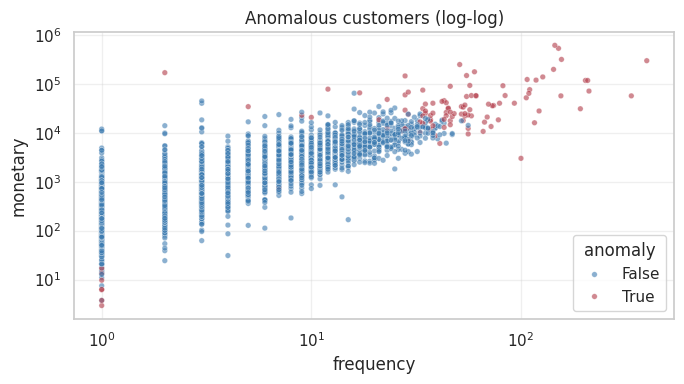

In [21]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.02, n_estimators=200, random_state=42).fit(Xs)
rfm["anomaly"] = iso.predict(Xs) == -1
rfm["anomaly_score"] = -iso.score_samples(Xs)

print(f"flagged {rfm.anomaly.sum():,} of {len(rfm):,} customers ({rfm.anomaly.mean():.1%})")
print(rfm[rfm.anomaly].nlargest(8, "anomaly_score")[
    ["recency", "frequency", "monetary", "segment"]])

fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(x=rfm.frequency, y=rfm.monetary, hue=rfm.anomaly, s=16, alpha=.6,
                palette={False: BLUE, True: RED}, ax=ax)
ax.set(xscale="log", yscale="log", title="Anomalous customers (log-log)")
plt.tight_layout(); plt.show()

## 15. Rules vs the data
The SQL layer assigns RFM segments with NTILE cut points. KMeans found its own.
Where they agree, the business rule is doing its job; where they diverge is
worth a conversation with whoever owns the segmentation.

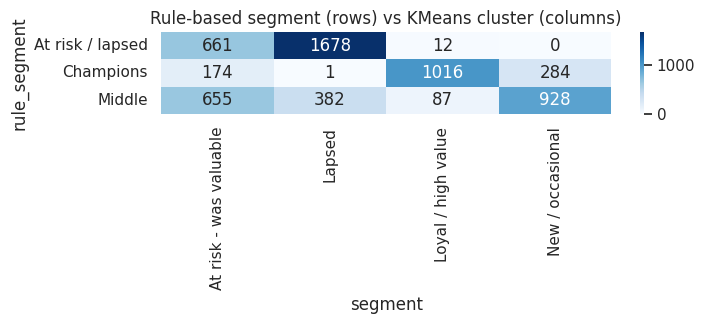

segment           At risk - was valuable  Lapsed  Loyal / high value  \
rule_segment                                                           
At risk / lapsed                     661    1678                  12   
Champions                            174       1                1016   
Middle                               655     382                  87   

segment           New / occasional  
rule_segment                        
At risk / lapsed                 0  
Champions                      284  
Middle                         928  


In [22]:
rfm["r_rule"] = pd.qcut(rfm.recency.rank(method="first", ascending=False), 5, labels=range(1, 6)).astype(int)
rfm["f_rule"] = pd.qcut(rfm.frequency.rank(method="first"), 5, labels=range(1, 6)).astype(int)
rfm["rule_segment"] = np.where((rfm.r_rule >= 4) & (rfm.f_rule >= 4), "Champions",
                       np.where(rfm.r_rule <= 2, "At risk / lapsed", "Middle"))

ct = pd.crosstab(rfm.rule_segment, rfm.segment)
fig, ax = plt.subplots(figsize=(7.5, 3.4))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Rule-based segment (rows) vs KMeans cluster (columns)")
plt.tight_layout(); plt.show()
print(ct)

## 16. pandas — cohort retention
Group customers by the month of their first purchase, then track whether they
come back. This is the analysis the Cohort dashboard page is built on, and it
is pure pandas: groupby, transform, pivot, unstack.

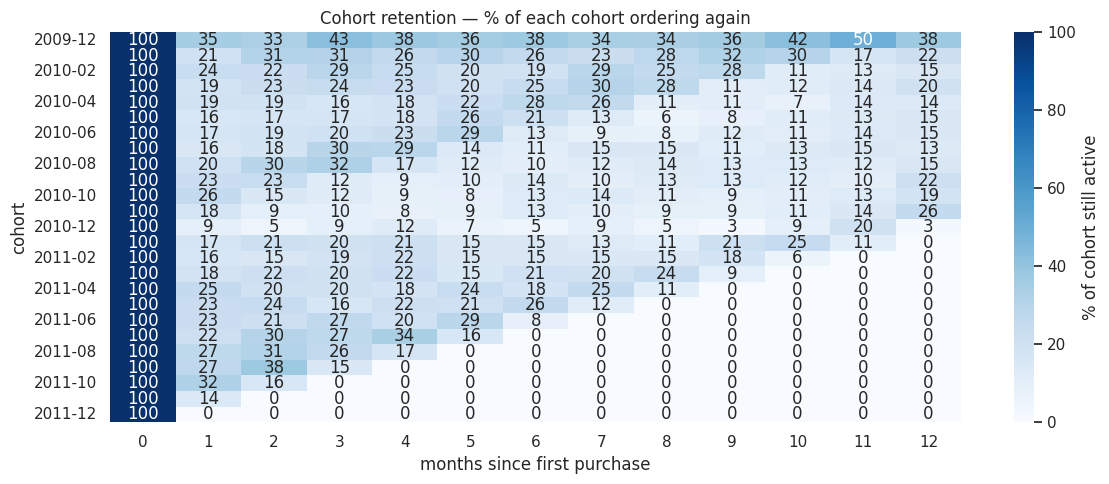

average retention curve (%):
period
0    100.00
1     20.30
2     20.20
3     19.00
4     17.30
5     15.10
6     13.50
7     12.70
8     10.60
9      9.80
10     9.00
11     9.20
12     9.50


In [23]:
coh = sale[sale.customer_id.notna()][["customer_id", "invoice_date", "line_revenue"]].copy()
coh["order_month"] = coh.invoice_date.dt.to_period("M")
# transform broadcasts the per-customer minimum back onto every one of their rows
coh["cohort"] = coh.groupby("customer_id").order_month.transform("min")
coh["period"] = (coh.order_month - coh.cohort).apply(lambda x: x.n)

matrix = (coh.groupby(["cohort", "period"]).customer_id.nunique()
             .unstack(fill_value=0))
retention = matrix.div(matrix[0], axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(retention.iloc[:, :13], annot=True, fmt=".0f", cmap="Blues",
            cbar_kws={"label": "% of cohort still active"}, ax=ax)
ax.set_title("Cohort retention — % of each cohort ordering again")
ax.set_xlabel("months since first purchase"); ax.set_ylabel("cohort")
plt.tight_layout(); plt.show()

print("average retention curve (%):")
print(retention.iloc[:, :13].mean().round(1).to_string())

## 17. pandas — pivot tables and reshaping
The same data in three shapes: wide for reading, long for plotting,
and a crosstab for proportions.

country       Australia      EIRE    France   Germany  Netherlands  United Kingdom
invoice_date                                                                      
2011-07        4,964.00 42,790.00 10,000.00 16,441.00        26.00      601,995.00
2011-08       22,489.00 18,354.00 13,811.00 19,221.00    40,328.00      608,047.00
2011-09        5,107.00 43,087.00 23,428.00 18,091.00    26,937.00      897,076.00
2011-10       17,151.00 24,318.00 33,485.00 31,638.00    40,709.00      938,975.00
2011-11        7,243.00 30,738.00 31,759.00 28,025.00    25,874.00    1,325,346.00
2011-12            0.00  7,341.00  7,295.00  7,984.00    11,728.00      592,622.00


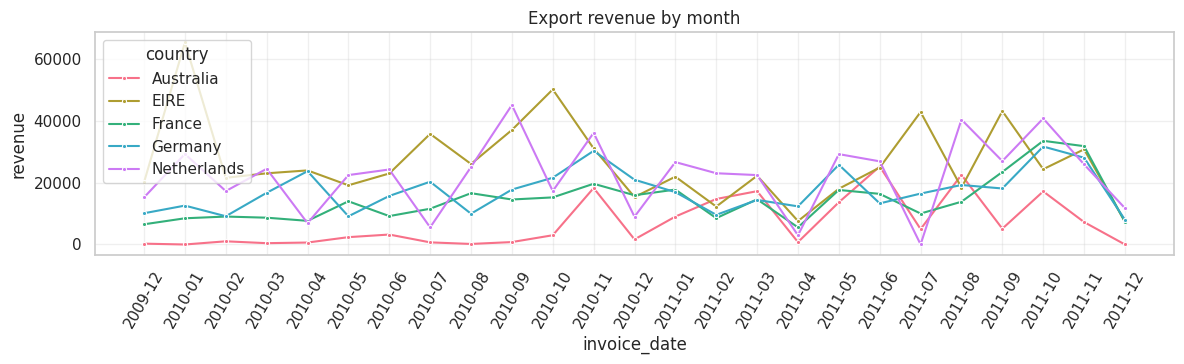

In [24]:
pivot = pd.pivot_table(
    sale[sale.country.isin(geo.head(6).index)],
    index=sale.invoice_date.dt.to_period("M").astype(str),
    columns="country", values="line_revenue", aggfunc="sum", fill_value=0)
print(pivot.tail(6).round(0).to_string())

# long form, which is what seaborn wants
long = pivot.reset_index().melt(id_vars="invoice_date", var_name="country",
                                value_name="revenue")
fig, ax = plt.subplots(figsize=(12, 3.8))
sns.lineplot(data=long[long.country != "United Kingdom"], x="invoice_date",
             y="revenue", hue="country", ax=ax, marker="o", markersize=3)
ax.set_title("Export revenue by month"); ax.tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

Binning with `cut` and `qcut`: fixed edges when the boundaries mean something,
quantiles when you want equal-sized groups.

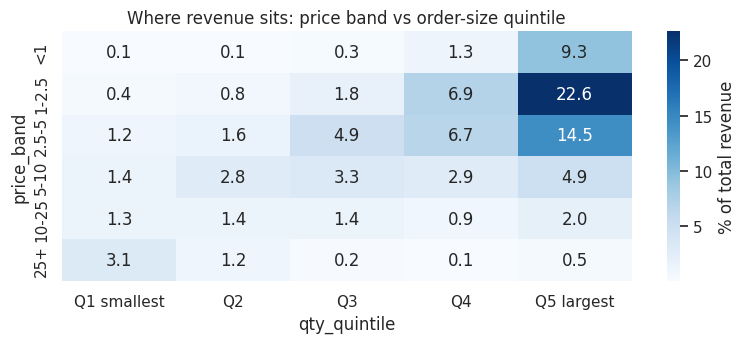

In [25]:
sale["price_band"] = pd.cut(sale.unit_price, [0, 1, 2.5, 5, 10, 25, np.inf],
                            labels=["<1", "1-2.5", "2.5-5", "5-10", "10-25", "25+"])
sale["qty_quintile"] = pd.qcut(sale.quantity.rank(method="first"), 5,
                               labels=["Q1 smallest", "Q2", "Q3", "Q4", "Q5 largest"])
band = pd.crosstab(sale.price_band, sale.qty_quintile,
                   values=sale.line_revenue, aggfunc="sum", normalize="all") * 100
fig, ax = plt.subplots(figsize=(8, 3.6))
sns.heatmap(band, annot=True, fmt=".1f", cmap="Blues", ax=ax,
            cbar_kws={"label": "% of total revenue"})
ax.set_title("Where revenue sits: price band vs order-size quintile")
plt.tight_layout(); plt.show()

## 18. NumPy — vectorisation, and why it matters at this scale
The same classification written three ways. The timing gap is the reason
the pipeline never loops over rows.

In [26]:
import time
sample = sale.head(200_000)

t0 = time.perf_counter()
out_loop = []
for q, p in zip(sample.quantity.values[:20_000], sample.unit_price.values[:20_000]):
    out_loop.append("bulk" if q >= 24 else ("retail" if p >= 5 else "small"))
t_loop = (time.perf_counter() - t0) * 10          # scaled to 200k for comparison

t0 = time.perf_counter()
out_apply = sample.apply(lambda r: "bulk" if r.quantity >= 24
                         else ("retail" if r.unit_price >= 5 else "small"), axis=1)
t_apply = time.perf_counter() - t0

t0 = time.perf_counter()
out_np = np.select(
    [sample.quantity.values >= 24, sample.unit_price.values >= 5],
    ["bulk", "retail"], default="small")
t_np = time.perf_counter() - t0

print(f"python loop (extrapolated) {t_loop:7.3f}s")
print(f"df.apply(axis=1)           {t_apply:7.3f}s   {t_apply/t_np:>6.0f}x slower than numpy")
print(f"np.select                  {t_np:7.3f}s")
print(f"\nresults identical: {(out_np == out_apply.values).all()}")

sale["order_type"] = np.select(
    [sale.quantity.values >= 24, sale.unit_price.values >= 5],
    ["bulk", "retail"], default="small")
print(sale.groupby("order_type").line_revenue.agg(["size", "sum"]))

python loop (extrapolated)   0.072s
df.apply(axis=1)             4.042s      710x slower than numpy
np.select                    0.006s

results identical: True


              size          sum
order_type                     
bulk        111341 8,902,576.25
retail      178746 4,671,670.65
small       751583 7,398,347.67


## 19. NumPy — bootstrap confidence interval
A point estimate without an interval invites false precision. Resampling
invoices 2,000 times gives an honest range for average order value, without
assuming the distribution is normal - which it very much is not.

average order value : GBP 523.31
95% CI (bootstrap)  : GBP 509.51 - GBP 539.21
median order value  : GBP 304.31

mean sits at the 76.2% percentile - the average is not a typical order


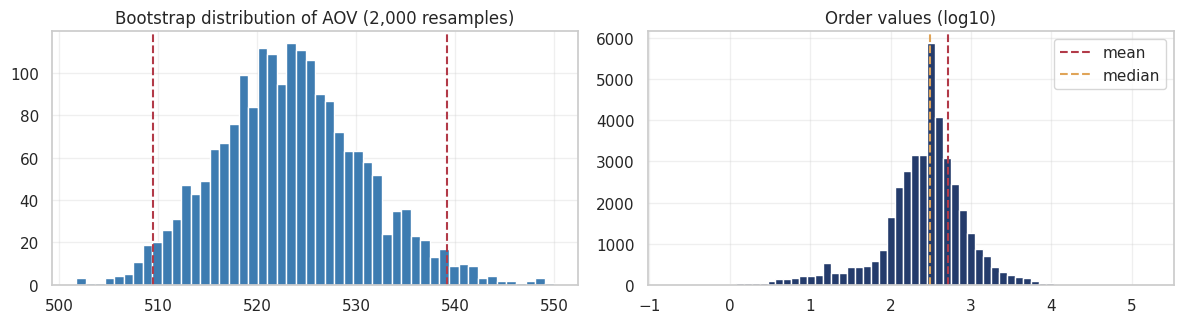

In [27]:
invoice_totals = (sale.groupby("invoice_no").line_revenue.sum().values)
rng = np.random.default_rng(42)

n_boot = 2_000
idx = rng.integers(0, len(invoice_totals), size=(n_boot, len(invoice_totals)))
boot_means = invoice_totals[idx].mean(axis=1)

lo, hi = np.percentile(boot_means, [2.5, 97.5])
print(f"average order value : GBP {invoice_totals.mean():,.2f}")
print(f"95% CI (bootstrap)  : GBP {lo:,.2f} - GBP {hi:,.2f}")
print(f"median order value  : GBP {np.median(invoice_totals):,.2f}")
print(f"\nmean sits at the {(invoice_totals < invoice_totals.mean()).mean():.1%} "
      f"percentile - the average is not a typical order")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].hist(boot_means, bins=50, color=BLUE)
ax[0].axvline(lo, color=RED, ls="--"); ax[0].axvline(hi, color=RED, ls="--")
ax[0].set_title(f"Bootstrap distribution of AOV ({n_boot:,} resamples)")
ax[1].hist(np.log10(invoice_totals.clip(min=.01)), bins=60, color=NAVY)
ax[1].axvline(np.log10(invoice_totals.mean()), color=RED, ls="--", label="mean")
ax[1].axvline(np.log10(np.median(invoice_totals)), color=AMBER, ls="--", label="median")
ax[1].set_title("Order values (log10)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 20. What this told the pipeline to do

| Finding | Pipeline decision |
|---|---|
| ~23% of lines have no customer id | keep for revenue, exclude from RFM/cohorts |
| C invoices are a material share of gross | keep and net off; three named revenue measures |
| one manual adjustment on a credit note | negative-revenue rule binds product lines only |
| zero-price rows are warehouse annotations | quarantine with a reason |
| POST/DOT/M/vouchers aren't products | flag as service lines |
| Sept–Nov peak | wholesale calendar; rolling average on the trend |
| UK ~85% of revenue | chart exports separately |
| ~21% of products make 80% of revenue | Pareto and ABC pages |
| high repeat rate, concentrated spend | RFM and cohort retention |